In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import ModelConfig
from membraneReactorModel import MembraneReactorModel


In [13]:
cfg = ModelConfig()
model = MembraneReactorModel(cfg)

result = model.solve()

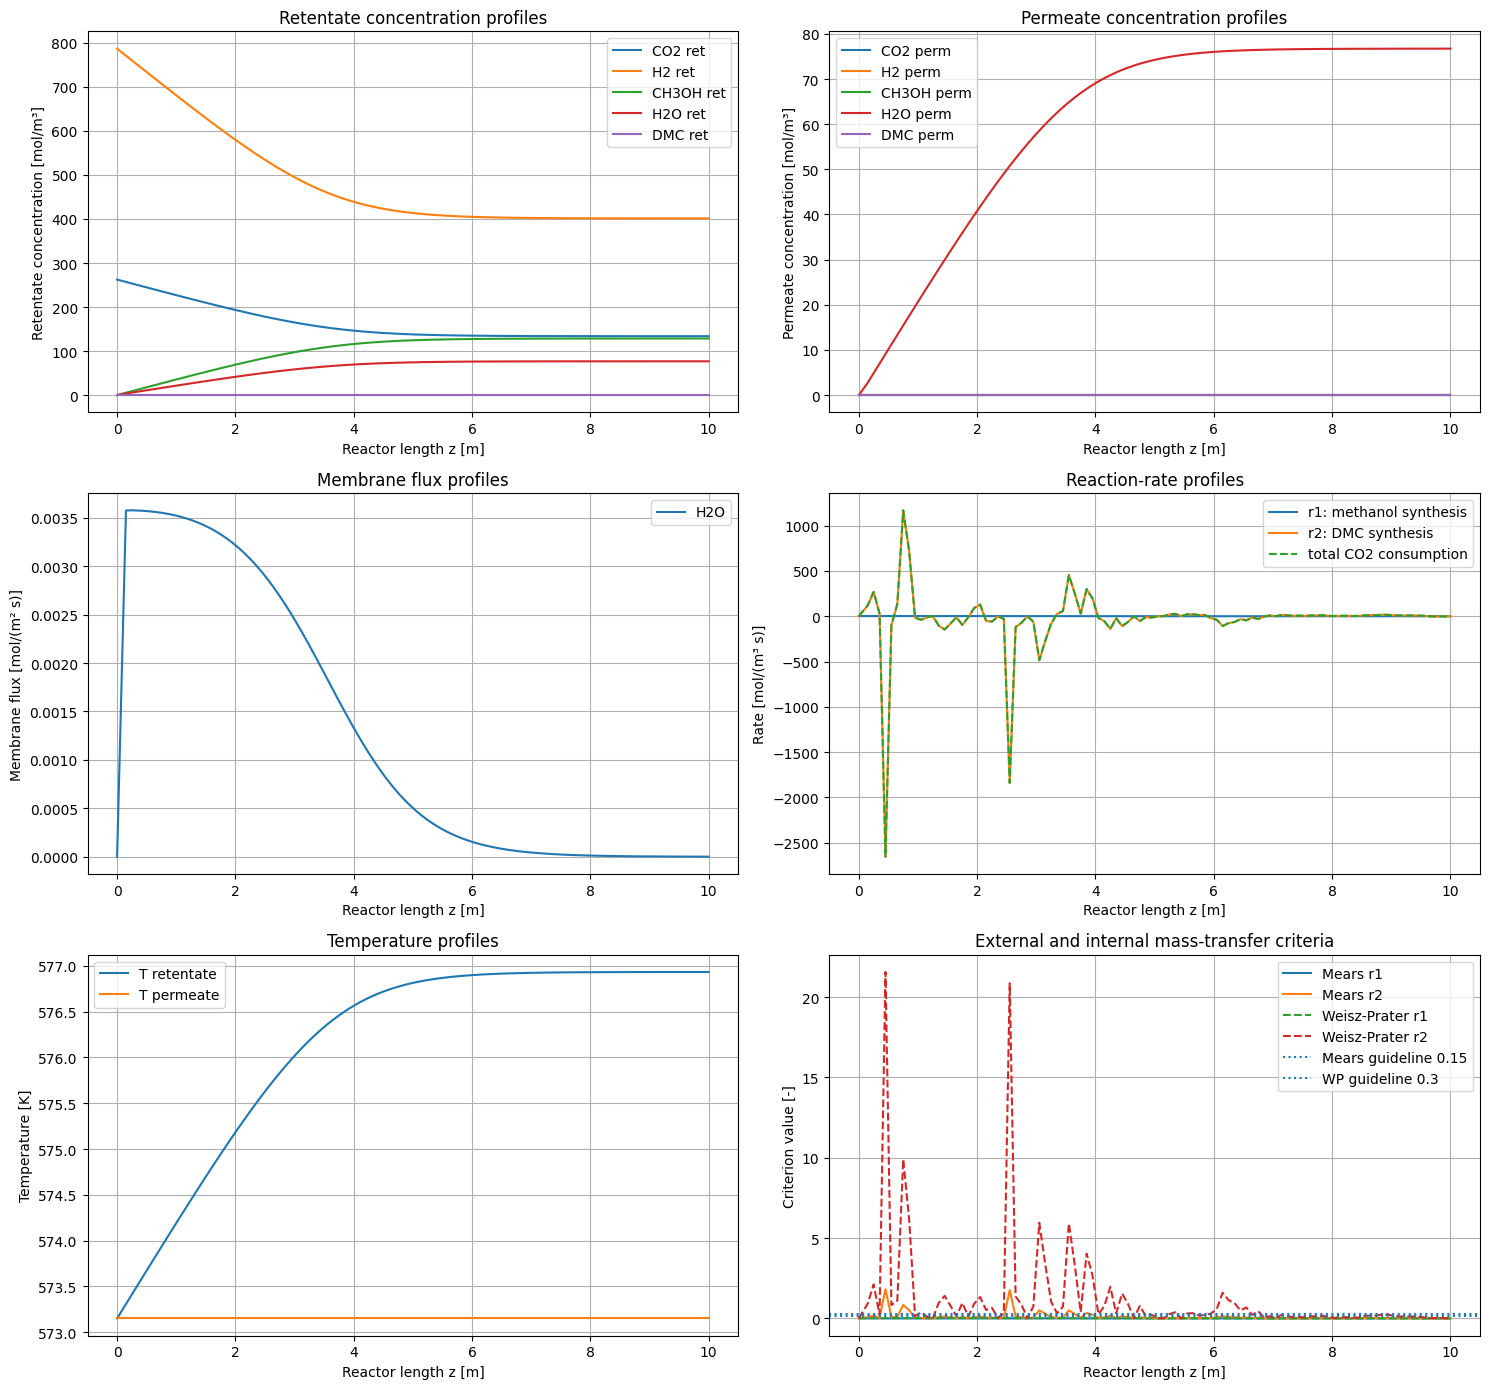

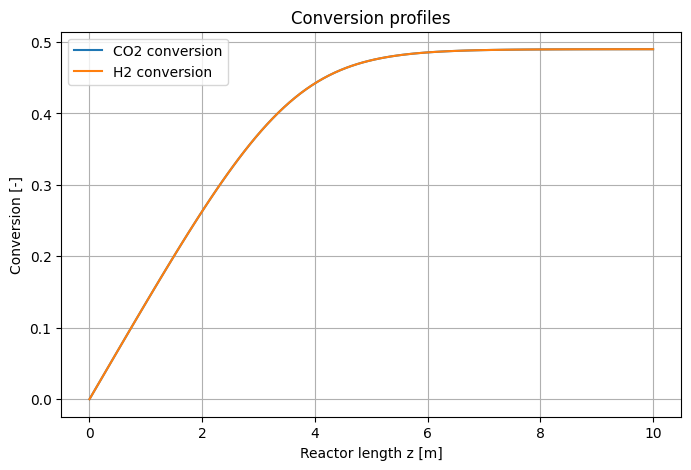

In [22]:
c_ret, T_ret, c_perm, T_perm = model.fields()
z = model.z_c
species = list(model.species_labels)
n_species = cfg.n_species

r1, r2 = model.reac.reaction_rates(c_ret, T_ret)
source = model.reac.species_source(c_ret, T_ret)
r_CO2_consumption = -source[:, 0]

P_species = np.asarray(cfg.P_species, dtype=float)
J_mem = P_species[None, :] * (c_ret - c_perm)  # [mol/(m2 s)]

c_in = cfg.inlet_concentration

X_CO2 = (c_in[0] - c_ret[:, 0]) / max(c_in[0], 1e-30)
X_H2 = (c_in[1] - c_ret[:, 1]) / max(c_in[1], 1e-30)

C_CO2 = np.maximum(c_ret[:, 0], 1e-30)
D_eff_CO2 = cfg.eps_p * cfg.particle_diffusivity[0] / cfg.tortuosity

# Mears criterion:
mears_r1, mears_r2 = model.mears_criterion()
wp_r1, wp_r2 = model.weisz_prater_criterion()

fig, axs = plt.subplots(3, 2, figsize=(15, 14))
axs = axs.ravel()

# 1. Retentate concentrations
ax = axs[0]
for i, name in enumerate(species):
    ax.plot(z, c_ret[:, i], label=f"{name} ret")
ax.set_xlabel("Reactor length z [m]")
ax.set_ylabel("Retentate concentration [mol/m³]")
ax.set_title("Retentate concentration profiles")
ax.grid(True)
ax.legend()

# 2. Permeate concentrations
ax = axs[1]
for i, name in enumerate(species):
    ax.plot(z, c_perm[:, i], label=f"{name} perm")
ax.set_xlabel("Reactor length z [m]")
ax.set_ylabel("Permeate concentration [mol/m³]")
ax.set_title("Permeate concentration profiles")
ax.grid(True)
ax.legend()

# 3. Membrane flux
ax = axs[2]
for i, name in enumerate(species):
    if np.any(np.abs(J_mem[:, i]) > 1e-20):
        ax.plot(z, J_mem[:, i], label=f"{name}")
ax.set_xlabel("Reactor length z [m]")
ax.set_ylabel("Membrane flux [mol/(m² s)]")
ax.set_title("Membrane flux profiles")
ax.grid(True)
ax.legend()

# 4. Reaction rates
ax = axs[3]
ax.plot(z, r1, label="r1: methanol synthesis")
ax.plot(z, r2, label="r2: DMC synthesis")
ax.plot(z, r_CO2_consumption, "--", label="total CO2 consumption")
ax.set_xlabel("Reactor length z [m]")
ax.set_ylabel("Rate [mol/(m³ s)]")
ax.set_title("Reaction-rate profiles")
ax.grid(True)
ax.legend()

# 5. Temperature profile
ax = axs[4]
ax.plot(z, T_ret, label="T retentate")
ax.plot(z, T_perm, label="T permeate")
ax.set_xlabel("Reactor length z [m]")
ax.set_ylabel("Temperature [K]")
ax.set_title("Temperature profiles")
ax.grid(True)
ax.legend()

# 6. Criteria and conversions
ax = axs[5]
ax.plot(z, mears_r1, label="Mears r1")
ax.plot(z, mears_r2, label="Mears r2")
ax.plot(z, wp_r1, "--", label="Weisz-Prater r1")
ax.plot(z, wp_r2, "--", label="Weisz-Prater r2")
ax.axhline(0.15, linestyle=":", label="Mears guideline 0.15")
ax.axhline(0.30, linestyle=":", label="WP guideline 0.3")
ax.set_xlabel("Reactor length z [m]")
ax.set_ylabel("Criterion value [-]")
ax.set_title("External and internal mass-transfer criteria")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# Separate useful conversion plot
plt.figure(figsize=(8, 5))
plt.plot(z, X_CO2, label="CO2 conversion")
plt.plot(z, X_H2, label="H2 conversion")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Conversion [-]")
plt.title("Conversion profiles")
plt.grid(True)
plt.legend()
plt.show()

In [25]:
cfg = ModelConfig()
    
cfg.T = 323.15
cfg.P = 200e5
cfg.r1_scale = 0.0
cfg.r2_scale = 1.0
cfg.feed_y = np.array([1/3, 0.0, 2/3, 0.0, 0.0])

model = MembraneReactorModel(cfg)
result = model.solve()

k2 inlet = 0.36358134542279164
k2 outlet = 0.36762480164191325
k2 max = 0.3676248019146228
k_eq = 1.5157360266147384e-06


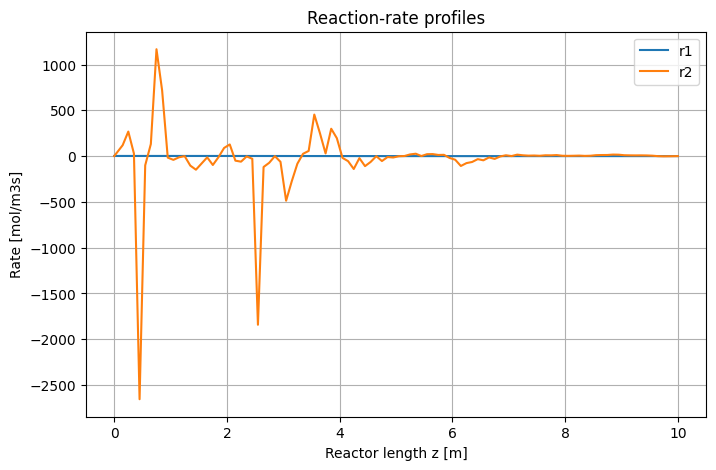

In [28]:
c_ret, T_ret, c_perm, T_perm = model.fields()

k2_profile = model.reac.k_eff_r2(T_ret)

print("k2 inlet =", k2_profile[0])
print("k2 outlet =", k2_profile[-1])
print("k2 max =", np.max(k2_profile))
print("k_eq =", model.reac.k2_eq_T(cfg.T))

plt.figure(figsize=(8, 5))
plt.plot(z, r1, label="r1")
plt.plot(z, r2, label="r2")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Rate [mol/m3s]")
plt.title("Reaction-rate profiles")
plt.grid(True)
plt.legend()
plt.show()

success: True
message: The solver successfully reached the end of the integration interval.
number of function evaluations: 346


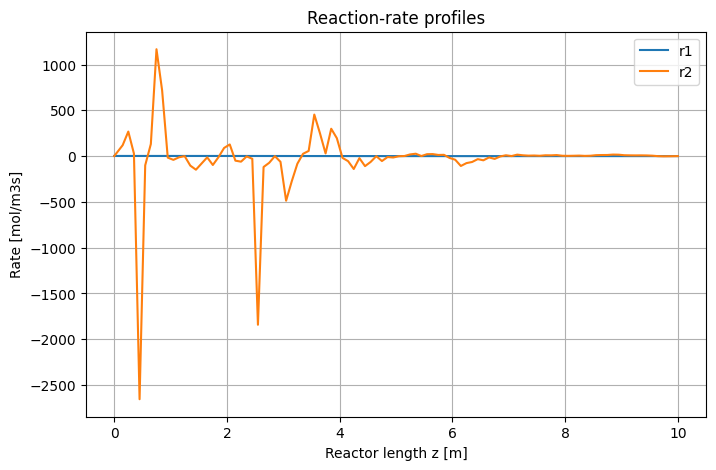

In [27]:
print("success:", result.success)
print("message:", result.message)
print("number of function evaluations:", result.nfev)

# Separate useful conversion plot
plt.figure(figsize=(8, 5))
plt.plot(z, r1, label="r1")
plt.plot(z, r2, label="r2")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Rate [mol/m3s]")
plt.title("Reaction-rate profiles")
plt.grid(True)
plt.legend()
plt.show()


In [15]:
c_ret, T_ret, c_perm, T_perm = model.fields()

k2_profile = model.reac.k_eff_r2(T_ret)

print("k2 inlet =", k2_profile[0])
print("k2 outlet =", k2_profile[-1])
print("k2 max =", np.max(k2_profile))
print("k_eq =", model.reac.k2_eq_T(cfg.T))

k2 inlet = 10827019.325794315
k2 outlet = 12527464.123887561
k2 max = 12527464.123887561
k_eq = 1.7639228044852852e-09
